In [1]:
!pip install ~/python_projects/SLIM

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Processing /home/mahdi/python_projects/SLIM
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for slim: filename=slim-0.1.0-py3-none-any.whl size=6438 sha256=1ac87a06b6ba23739bbaa4d3eb84e1deac630f39adc0235e9abb2e7b20696391
  Stored in directory: /tmp/pip-ephem-wheel-cache-d_hp75fs/wheels/62/95/1b/e583e94984c50a58fbdc545d261956af3fba2cee78545e6ace
Successfully built slim
  Attempting uninstall: slim
    Found existing installation: slim 0.1.0
    Uninstalling slim-0.1.0:
      Successfully uninstalled slim-0.1.0

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# SLIM simulations

- Ergodic (irreducible and aperiodic)
- Irreducible but periodic
- Reducible

In [1]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from slim.model import SLIM

from sklearn.decomposition import PCA

In [2]:
mpl.rcParams["text.usetex"] = True

sns.set(style="whitegrid", context="talk")

ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
sns.set_palette(ibm_palette)

In [3]:
def sample(matrix, x_0, N, prng=None):
    d = matrix.shape[0]
    samples = np.empty(N, dtype=int)
    if not prng:
        prng = np.random.default_rng()
    curr = x_0
    samples[0] = curr
    for t in tqdm(range(1, N), leave=False):
        curr = prng.choice(d, p=matrix[curr])
        samples[t] = curr
    return samples

In [13]:
M = {}
dim = 3
M['ergodic'] = np.array([[.1, .9, .0], [0, .2, .8], [.7, 0, .3]])  #np.array([[.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
M['irreducible'] = np.array([[0, 1, 0], [.5, 0, .5], [0, 1, 0]]) # np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])
M['reducible'] = np.array([[1, 0,  0], [.5, 0, .5], [0, 0, 1]])

N = 100_000
samples = {mtype: {x_0: sample(matrix, x_0, N) for x_0 in range(dim)} for (mtype, matrix) in M.items()}

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

In [5]:
P = M['ergodic']
pi = (v := np.linalg.eig(P.T)[1][:, np.argmin(abs(np.linalg.eigvals(P.T) - 1))].real) / v.sum()
pi

array([0.29319372, 0.32984293, 0.37696335])

In [9]:
N = 50_000
d = 3
n_seeds = 50
lr = 0.005
norm = 'fro'

all_Es = []
all_V_Es = []
for idx in tqdm(range(n_seeds)):
    x_0 = np.random.randint(0, d)
    samples = sample(M['ergodic'], x_0, N)
    model = SLIM(d, sensor=np.eye(d, dtype=float), track_dyn=True)
    # random init
    model.W = np.random.rand(d, d)
    model.W /= model.W.sum(axis=1, keepdims=True)
    model.W_hist = [model.W]

    model.fit(samples, learning_rate=lr)
    Es = np.array(model.W_hist) - M['ergodic']
    all_Es.append(Es)

    if norm == 'max':
        M_norm = np.max(np.abs(M['ergodic']))
        V_Es = [np.max(np.abs(E)) for E in Es]
    else:
        M_norm = np.linalg.norm(M['ergodic'], ord=norm)
        V_Es = [np.linalg.norm(E, ord=norm) for E in Es]
    all_V_Es.append(V_Es)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

...

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

In [11]:
all_trajectories = np.vstack(all_Es).reshape(n_seeds, N, d**2)
ub_radius = np.sqrt(max(pi)/min(pi)) * np.sqrt(lr/(2-lr)) * np.sqrt(2 * d)

pooled_data_flat = np.vstack(all_trajectories)

pca = PCA(n_components=2)
pca.fit(pooled_data_flat)
print(f'variance explained by pc1 and pc2: {pca.explained_variance_ratio_.sum() * 100:0.2f}')

trajectories_2d = [pca.transform(traj) for traj in all_trajectories]

pc1_min, pc1_max = -1.5, 1.5
pc2_min, pc2_max = -1.5, 1.5
grid_pc1, grid_pc2 = np.meshgrid(np.linspace(pc1_min, pc1_max, 20), np.linspace(pc2_min, pc2_max, 20))
grid_2d = np.column_stack([grid_pc1.ravel(), grid_pc2.ravel()])
grid_flat = pca.inverse_transform(grid_2d)

theta = np.linspace(0, 2*np.pi, 200)
x_bound_2d = ub_radius * np.cos(theta)
y_bound_2d = ub_radius * np.sin(theta)

variance explained by pc1 and pc2: 80.46


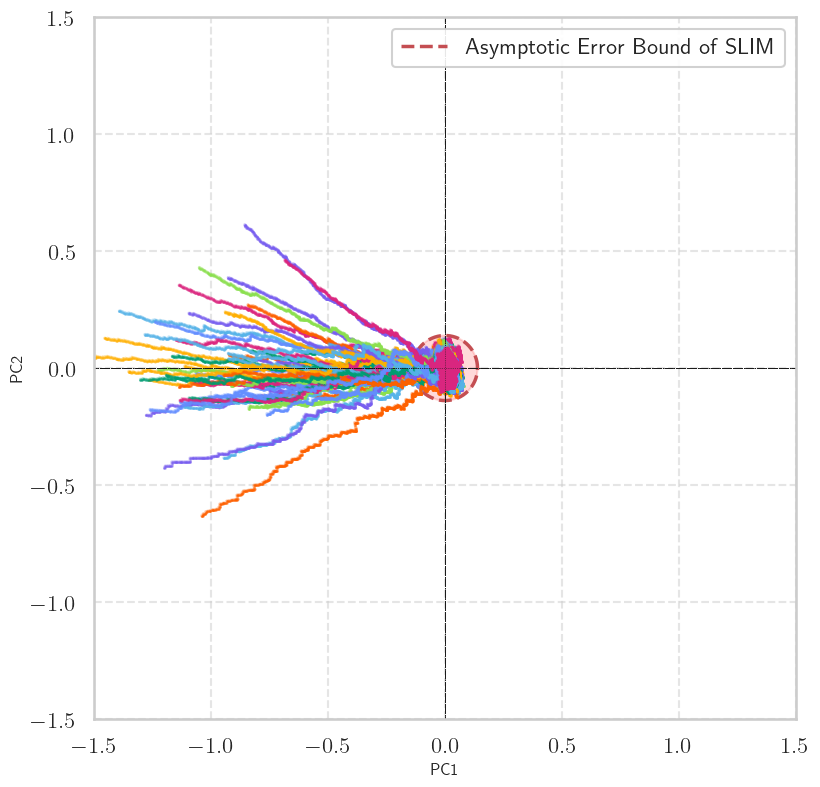

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))

ax.plot(x_bound_2d, y_bound_2d, 'r--', linewidth=2.5, label=f'Asymptotic Error Bound of SLIM')
ax.fill(x_bound_2d, y_bound_2d, color='red', alpha=0.15)

colors = ['g', 'b', 'y', 'orange']
for i, traj_2d in enumerate(trajectories_2d):
    ax.plot(traj_2d[:, 0], traj_2d[:, 1], 'o-', markersize=1, alpha=0.3)

    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
    ax.axvline(0, color='k', linewidth=0.5, linestyle=':')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./SLIM_UUB.png', dpi=300, bbox_inches='tight')
plt.show()

# Irreducible and Periodic

In [14]:
P = M['irreducible']
pi = (v := np.linalg.eig(P.T)[1][:, np.argmin(abs(np.linalg.eigvals(P.T) - 1))].real) / v.sum()
pi

array([0.25, 0.5 , 0.25])

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/49999 [00:00<?, ?it/s]

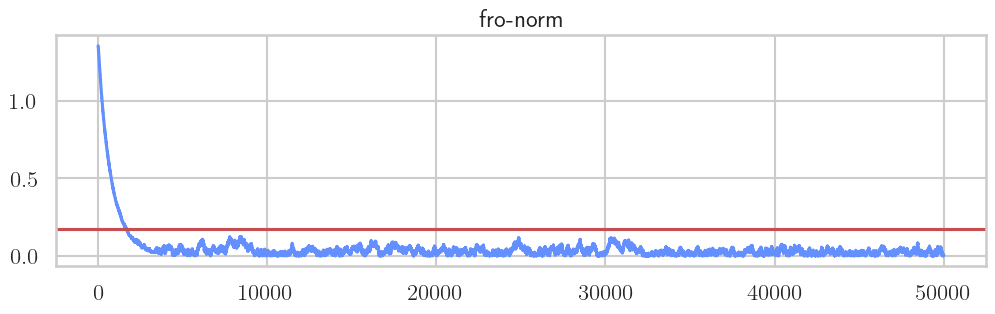

In [16]:
N = 50_000
d = 3
n_seeds = 1
lr = 0.005
norm = 'fro'

all_Es = []
all_V_Es = []

for _ in tqdm(range(n_seeds)):
    x_0 = np.random.randint(0, d)
    samples = sample(M['irreducible'], x_0, N)
    model = SLIM(d, sensor=np.eye(d, dtype=float), track_dyn=True)
    # random init
    model.W = np.random.rand(d, d)
    model.W /= model.W.sum(axis=1, keepdims=True)
    model.W_hist = [model.W]

    model.fit(samples, learning_rate=lr)
    Es = np.array(model.W_hist) - M['irreducible']
    all_Es.append(Es)

    if norm == 'max':
        M_norm = np.max(np.abs(M['irreducible']))
        V_Es = [np.max(np.abs(E)) for E in Es]
    else:
        M_norm = np.linalg.norm(M['irreducible'], ord=norm)
        V_Es = [np.linalg.norm(E, ord=norm) for E in Es]
    all_V_Es.append(V_Es)


ub_radius = np.sqrt(max(pi)/min(pi)) * np.sqrt(lr/(2-lr)) * np.sqrt(2 * d)

plt.figure(figsize=(12,3))
ax = sns.lineplot(all_V_Es[0], ax=plt.subplot())
ax.axhline(ub_radius, c='r')
ax.set_title(f'{norm}-norm')
plt.show()

---